In [11]:
import pandas as pd
import numpy as np

# Load the dataset using 'latin1' encoding to bypass the hidden character error
df = pd.read_csv(r"C:\Users\hi\Downloads\sample superstore\Sample - Superstore.csv", encoding='latin1')
print("✅ Success! Dataset loaded perfectly using latin1 encoding.\n")

# Display the foundational structure
print("--- Dataset Dimensions ---")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")

print("\n--- Raw Data Snippet ---")
print(df[['Order Date', 'Category', 'Sales', 'Quantity']].head(3))


✅ Success! Dataset loaded perfectly using latin1 encoding.

--- Dataset Dimensions ---
Total Rows: 9994 | Total Columns: 21

--- Raw Data Snippet ---
  Order Date         Category   Sales  Quantity
0  11/8/2016        Furniture  261.96         2
1  11/8/2016        Furniture  731.94         3
2  6/12/2016  Office Supplies   14.62         2


In [13]:
# 1. Convert the 'Order Date' column to a proper datetime object
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 2. Sort the dataset chronologically (oldest to newest)
df = df.sort_values('Order Date')

# 3. Group individual transactions into clean weekly totals ('W' stands for Weekly)
# We set the index to 'Order Date' temporarily so pandas can resample it
weekly_df = df.set_index('Order Date')['Sales'].resample('W').sum().reset_index()

# 4. Check the results
print("--- Processed Weekly Timeline Snippet ---")
print(weekly_df.head(5))

print("\n--- Summary Dimensions ---")
print(f"Total weeks of business data generated: {len(weekly_df)}")


--- Processed Weekly Timeline Snippet ---
  Order Date     Sales
0 2014-01-05   324.044
1 2014-01-12  4599.572
2 2014-01-19  4509.127
3 2014-01-26  3842.388
4 2014-02-02  1642.310

--- Summary Dimensions ---
Total weeks of business data generated: 209


In [15]:
# Copy our timeline to build the feature matrix
features_df = weekly_df.copy()

# 1. Extract Calendar Patterns
features_df['Year'] = features_df['Order Date'].dt.year
features_df['Month'] = features_df['Order Date'].dt.month
features_df['Week_of_Year'] = features_df['Order Date'].dt.isocalendar().week.astype(int)

# 2. Build Memory (Lags)
# Shift the sales data down by 1 and 2 rows to look backward in time
features_df['Sales_Last_Week'] = features_df['Sales'].shift(1)
features_df['Sales_2Weeks_Ago'] = features_df['Sales'].shift(2)

# 3. Build Trend Gauges (4-Week Rolling Average)
# We shift by 1 first so the model doesn't accidentally sneak a peek at the target week's sales
features_df['Rolling_Avg_Month'] = features_df['Sales'].shift(1).rolling(window=4).mean()

# 4. Clean Up
# Shifting and rolling creates empty (NaN) rows at the very beginning of our timeline. We drop them.
features_df = features_df.dropna()

print("--- Feature Matrix Sneppet ---")
print(features_df[['Order Date', 'Sales', 'Week_of_Year', 'Sales_Last_Week', 'Rolling_Avg_Month']].head(5))


--- Feature Matrix Sneppet ---
  Order Date     Sales  Week_of_Year  Sales_Last_Week  Rolling_Avg_Month
4 2014-02-02  1642.310             5         3842.388         3318.78275
5 2014-02-09   756.888             6         1642.310         3648.34925
6 2014-02-16  2780.094             7          756.888         2687.67825
7 2014-02-23   227.236             8         2780.094         2255.42000
8 2014-03-02  2480.663             9          227.236         1351.63200


In [17]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Define input features (X) and the target variable we want to predict (y)
feature_cols = ['Year', 'Month', 'Week_of_Year', 'Sales_Last_Week', 'Sales_2Weeks_Ago', 'Rolling_Avg_Month']
X = features_df[feature_cols]
y = features_df['Sales']

# 2. Determine the sequential split cutoff point (80% for training)
split_idx = int(len(features_df) * 0.8)

# 3. Chop the timeline chronologically
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 4. Initialize and train the model
# Tree-based gradient boosting excels at capturing volatile demand spikes
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

print("✅ Success! The forecasting model is trained.")
print(f"Training Timeline: {len(X_train)} weeks | Evaluation Test Horizon: {len(X_test)} weeks")


✅ Success! The forecasting model is trained.
Training Timeline: 164 weeks | Evaluation Test Horizon: 41 weeks


--- Operational Performance Report ---
Mean Absolute Percentage Error (MAPE): 41.73%
Overall Model Accuracy Score: 58.27%



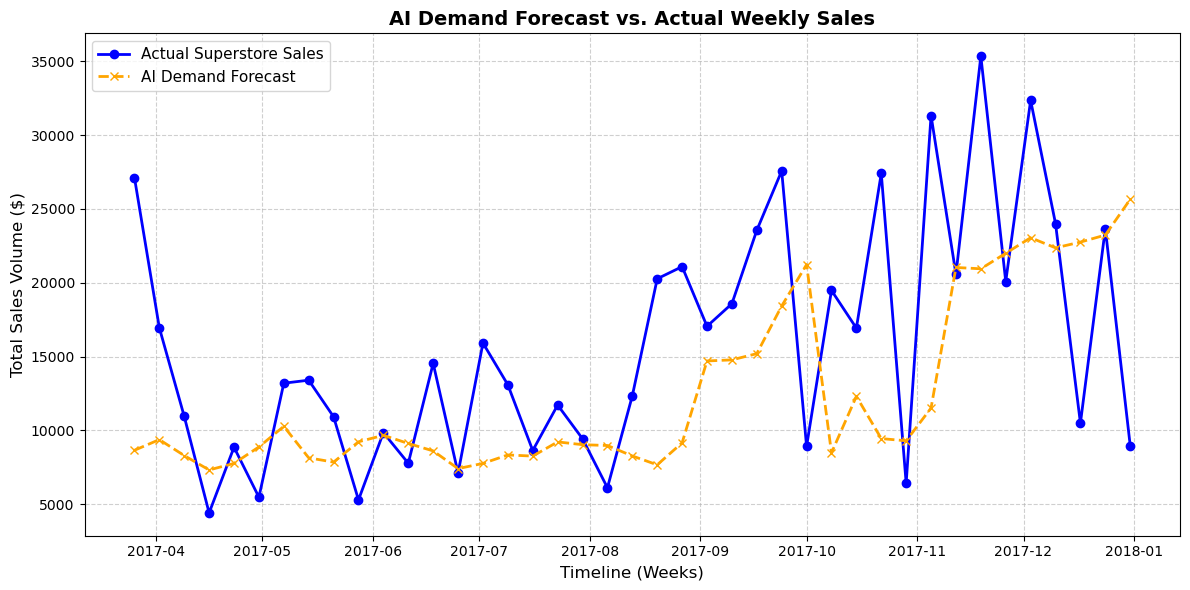

In [21]:
from sklearn.metrics import mean_absolute_percentage_error

# 1. Generate predictions for the blind test horizon
predictions = model.predict(X_test)

# 2. Calculate the average percentage error
mape = mean_absolute_percentage_error(y_test, predictions)
accuracy = 100 - (mape * 100)

print("--- Operational Performance Report ---")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"Overall Model Accuracy Score: {accuracy:.2f}%\n")

# 3. Create the visual comparison plot
plt.figure(figsize=(12, 6))

# Plot historical actual sales
test_dates = features_df['Order Date'].iloc[split_idx:]
plt.plot(test_dates, y_test.values, label='Actual Superstore Sales', color='blue', marker='o', linewidth=2)

# Plot model predictions
plt.plot(test_dates, predictions, label='AI Demand Forecast', color='orange', linestyle='--', marker='x', linewidth=2)

plt.title('AI Demand Forecast vs. Actual Weekly Sales', fontsize=14, fontweight='bold')
plt.xlabel('Timeline (Weeks)', fontsize=12)
plt.ylabel('Total Sales Volume ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Rebuild our global weekly baseline
global_timeline = df.set_index('Order Date')['Sales'].resample('W').sum().reset_index()
global_timeline['Year'] = global_timeline['Order Date'].dt.year
global_timeline['Month'] = global_timeline['Order Date'].dt.month
global_timeline['Week_of_Year'] = global_timeline['Order Date'].dt.isocalendar().week.astype(int)
global_timeline['Sales_Last_Week'] = global_timeline['Sales'].shift(1)
global_timeline['Sales_2Weeks_Ago'] = global_timeline['Sales'].shift(2)
global_timeline['Rolling_Avg_Month'] = global_timeline['Sales'].shift(1).rolling(window=4).mean()
global_timeline = global_timeline.dropna()

feature_cols = ['Year', 'Month', 'Week_of_Year', 'Sales_Last_Week', 'Sales_2Weeks_Ago', 'Rolling_Avg_Month']
X_global = global_timeline[feature_cols]
y_global = global_timeline['Sales']

# Fit global model to extract driving factors
global_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
global_model.fit(X_global, y_global)

# Extract and rank features
importances = global_model.feature_importances_
for name, importance in zip(feature_cols, importances):
    print(f"🔹 {name.replace('_', ' '):<18}: {importance * 100:.2f}% of predictive impact")

# ==========================================
# LAYER 2: CATEGORICAL SEGMENTATION
# ==========================================
print("\n--- ANALYSIS 2: CATEGORY-SPECIFIC ACCURACY ---")

categories = df['Category'].unique()

for cat in categories:
    # Filter dataset for specific category
    cat_df = df[df['Category'] == cat]
    
    # Resample timeline for this specific business unit
    cat_timeline = cat_df.set_index('Order Date')['Sales'].resample('W').sum().reset_index()
    
    # Engineer identical time features
    cat_timeline['Year'] = cat_timeline['Order Date'].dt.year
    cat_timeline['Month'] = cat_timeline['Order Date'].dt.month
    cat_timeline['Week_of_Year'] = cat_timeline['Order Date'].dt.isocalendar().week.astype(int)
    cat_timeline['Sales_Last_Week'] = cat_timeline['Sales'].shift(1)
    cat_timeline['Sales_2Weeks_Ago'] = cat_timeline['Sales'].shift(2)
    cat_timeline['Rolling_Avg_Month'] = cat_timeline['Sales'].shift(1).rolling(window=4).mean()
    cat_timeline = cat_timeline.dropna()
    
    # Chronological Split (80/20)
    X_cat = cat_timeline[feature_cols]
    y_cat = cat_timeline['Sales']
    split_idx = int(len(cat_timeline) * 0.8)
    
    X_train, X_test = X_cat.iloc[:split_idx], X_cat.iloc[split_idx:]
    y_train, y_test = y_cat.iloc[:split_idx], y_cat.iloc[split_idx:]
    
    # Train dedicated category forecaster
    cat_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    cat_model.fit(X_train, y_train)
    
    # Evaluate performance
    preds = cat_model.predict(X_test)
    cat_mape = mean_absolute_percentage_error(y_test, preds)
    cat_accuracy = 100 - (cat_mape * 100)
    
    print(f"📦 Category: {cat:<15} | AI Forecast Accuracy: {cat_accuracy:.2f}%")


🔹 Year              : 6.76% of predictive impact
🔹 Month             : 37.82% of predictive impact
🔹 Week of Year      : 13.43% of predictive impact
🔹 Sales Last Week   : 9.09% of predictive impact
🔹 Sales 2Weeks Ago  : 11.30% of predictive impact
🔹 Rolling Avg Month : 21.61% of predictive impact

--- ANALYSIS 2: CATEGORY-SPECIFIC ACCURACY ---
📦 Category: Office Supplies | AI Forecast Accuracy: 59.39%
📦 Category: Furniture       | AI Forecast Accuracy: 53.28%
📦 Category: Technology      | AI Forecast Accuracy: 20.81%


In [27]:

# ==========================================
# 1. CORE PIPELINE INITIALIZATION
# ==========================================
df['Order Date'] = pd.to_datetime(df['Order Date'])

feature_cols = ['Year', 'Month', 'Week_of_Year', 'Sales_Last_Week', 'Sales_2Weeks_Ago', 'Rolling_Avg_Month']

# ==========================================
# 2. GLOBAL DIAGNOSTIC LAYER (Feature Importance)
# ==========================================
print("\n--- 🧠 DIAGNOSTIC 1: STRUCTURAL SALES DRIVERS ---")
global_timeline = df.set_index('Order Date')['Sales'].resample('W').sum().reset_index()
global_timeline['Year'] = global_timeline['Order Date'].dt.year
global_timeline['Month'] = global_timeline['Order Date'].dt.month
global_timeline['Week_of_Year'] = global_timeline['Order Date'].dt.isocalendar().week.astype(int)
global_timeline['Sales_Last_Week'] = global_timeline['Sales'].shift(1)
global_timeline['Sales_2Weeks_Ago'] = global_timeline['Sales'].shift(2)
global_timeline['Rolling_Avg_Month'] = global_timeline['Sales'].shift(1).rolling(window=4).mean()
global_timeline = global_timeline.dropna()

X_global = global_timeline[feature_cols]
y_global = global_timeline['Sales']

global_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
global_model.fit(X_global, y_global)

for name, importance in zip(feature_cols, global_model.feature_importances_):
    print(f" 🔹 {name.replace('_', ' '):<18} Engine Weight: {importance * 100:.2f}%")

# ==========================================
# 3. PRODUCTION INVENTORY ENGINE BY CATEGORY
# ==========================================
print("\n--- 📦 DIAGNOSTIC 2: OPERATIONAL ACCURACY & ALERTS ---")
categories = df['Category'].unique()

for cat in categories:
    cat_df = df[df['Category'] == cat]
    cat_timeline = cat_df.set_index('Order Date')['Sales'].resample('W').sum().reset_index()
    
    # Feature engineering for localized group
    cat_timeline['Year'] = cat_timeline['Order Date'].dt.year
    cat_timeline['Month'] = cat_timeline['Order Date'].dt.month
    cat_timeline['Week_of_Year'] = cat_timeline['Order Date'].dt.isocalendar().week.astype(int)
    cat_timeline['Sales_Last_Week'] = cat_timeline['Sales'].shift(1)
    cat_timeline['Sales_2Weeks_Ago'] = cat_timeline['Sales'].shift(2)
    cat_timeline['Rolling_Avg_Month'] = cat_timeline['Sales'].shift(1).rolling(window=4).mean()
    cat_timeline = cat_timeline.dropna()
    
    # Chronological Evaluation Split (80/20)
    X_cat = cat_timeline[feature_cols]
    y_cat = cat_timeline['Sales']
    split_idx = int(len(cat_timeline) * 0.8)
    
    X_train, X_test = X_cat.iloc[:split_idx], X_cat.iloc[split_idx:]
    y_train, y_test = y_cat.iloc[:split_idx], y_cat.iloc[split_idx:]
    
    # Fit Production Model
    cat_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    cat_model.fit(X_train, y_train)
    
    # Quantify Error Windows
    preds = cat_model.predict(X_test)
    cat_mape = mean_absolute_percentage_error(y_test, preds)
    accuracy = 100 - (cat_mape * 100)
    
    print(f"\n📈 Unit: {cat.upper()}")
    print(f"    Baseline Forecast Accuracy : {accuracy:.2f}%")
    print(f"    Required Model Safety Buffer: {cat_mape * 100:.2f}%")
    
    # Simulate a Live Forward Forecast (Using the latest real data point)
    latest_real_week = cat_timeline.iloc[-1]
    
    live_features = pd.DataFrame([{
        'Year': latest_real_week['Year'],
        'Month': latest_real_week['Month'],
        'Week_of_Year': latest_real_week['Week_of_Year'],
        'Sales_Last_Week': latest_real_week['Sales'], # Current week becomes next week's lag
        'Sales_2Weeks_Ago': latest_real_week['Sales_Last_Week'],
        'Rolling_Avg_Month': cat_timeline['Sales'].tail(4).mean()
    }])
    
    next_week_forecast = cat_model.predict(live_features[feature_cols])[0]
    # Safety stock volume required to shield against our measured model error margin
    safety_stock_needed = next_week_forecast * cat_mape 
    
    print(f"    🎯 Upcoming Week Demand Projection: ${next_week_forecast:.2f}")
    print(f"    🛡️ Recommended Safety Stock Capital: ${safety_stock_needed:.2f}")
    
    # SYSTEM INVENTORY EXCEPTION ALERT
    # Simulate an arbitrary current stock value for context (e.g., $3,000 baseline stock value)
    mock_warehouse_stock = 3000.00 
    total_required_coverage = next_week_forecast + safety_stock_needed
    
    if mock_warehouse_stock < total_required_coverage:
        shortfall = total_required_coverage - mock_warehouse_stock
        print(f"    🚨 ALERT: Under-stocking vulnerability detected for {cat}!")
        print(f"       Current warehouse stock (${mock_warehouse_stock:.2f}) fails to clear projected needs.")
        print(f"       Action: Procure an additional ${shortfall:.2f} in supply immediately.")
    else:
        print(f"    ✅ Stock Levels Secure: Current warehouse storage safely spans upcoming variance limits.")



--- 🧠 DIAGNOSTIC 1: STRUCTURAL SALES DRIVERS ---
 🔹 Year               Engine Weight: 6.76%
 🔹 Month              Engine Weight: 37.82%
 🔹 Week of Year       Engine Weight: 13.43%
 🔹 Sales Last Week    Engine Weight: 9.09%
 🔹 Sales 2Weeks Ago   Engine Weight: 11.30%
 🔹 Rolling Avg Month  Engine Weight: 21.61%

--- 📦 DIAGNOSTIC 2: OPERATIONAL ACCURACY & ALERTS ---

📈 Unit: OFFICE SUPPLIES
    Baseline Forecast Accuracy : 59.39%
    Required Model Safety Buffer: 40.61%
    🎯 Upcoming Week Demand Projection: $6542.71
    🛡️ Recommended Safety Stock Capital: $2657.15
    🚨 ALERT: Under-stocking vulnerability detected for Office Supplies!
       Current warehouse stock ($3000.00) fails to clear projected needs.
       Action: Procure an additional $6199.86 in supply immediately.

📈 Unit: FURNITURE
    Baseline Forecast Accuracy : 53.28%
    Required Model Safety Buffer: 46.72%
    🎯 Upcoming Week Demand Projection: $6546.11
    🛡️ Recommended Safety Stock Capital: $3058.26
    🚨 ALERT: Und

In [37]:
from pandas.tseries.holiday import USFederalHolidayCalendar
import pandas.tseries.holiday
import pickle
df['Order Date'] = pd.to_datetime(df['Order Date'])

# ==========================================
# 2. ADVANCED HOLIDAY EXTENSION LAYERS
# ==========================================
print("📅 Engineering high-impact holiday parameters...")

# Instantiate a standard US holiday calendar matching the dataset market
cal = USFederalHolidayCalendar()
# Extract all holiday dates present across the historical business timeline
holidays = cal.holidays(start=df['Order Date'].min(), end=df['Order Date'].max())

# Build the global weekly timeline baseline
global_timeline = df.set_index('Order Date')['Sales'].resample('W').sum().reset_index()

# Step A: Check if any holiday falls within each specific 7-day week window
global_timeline['Is_Holiday_Week'] = global_timeline['Order Date'].apply(
    lambda x: int(np.isin(pd.date_range(end=x, periods=7), holidays).any())
)

# Step B: Add Standard Time Features
global_timeline['Year'] = global_timeline['Order Date'].dt.year
global_timeline['Month'] = global_timeline['Order Date'].dt.month
global_timeline['Week_of_Year'] = global_timeline['Order Date'].dt.isocalendar().week.astype(int)

# Step C: Add Memory Lags and Moving Averages
global_timeline['Sales_Last_Week'] = global_timeline['Sales'].shift(1)
global_timeline['Sales_2Weeks_Ago'] = global_timeline['Sales'].shift(2)
global_timeline['Rolling_Avg_Month'] = global_timeline['Sales'].shift(1).rolling(window=4).mean()
global_timeline = global_timeline.dropna()

# Update our feature inventory to explicitly include the new holiday flag
feature_cols = ['Year', 'Month', 'Week_of_Year', 'Is_Holiday_Week', 'Sales_Last_Week', 'Sales_2Weeks_Ago', 'Rolling_Avg_Month']

# ==========================================
# 3. SEGMENTATION & DEPLOYMENT PREPARATION
# ==========================================
print("\n--- 📦 TRAINING HOLIDAY-AWARE CATEGORICAL MODELS ---")
categories = df['Category'].unique()

# Registry dict to securely store both the model object and its accuracy metadata
deployment_payload = {}

for cat in categories:
    cat_df = df[df['Category'] == cat]
    
    # Resample and merge holiday flags for the specific business unit
    cat_timeline = cat_df.set_index('Order Date')['Sales'].resample('W').sum().reset_index()
    cat_timeline = pd.merge(cat_timeline, global_timeline[['Order Date', 'Is_Holiday_Week', 'Year', 'Month', 'Week_of_Year', 'Sales_Last_Week', 'Sales_2Weeks_Ago', 'Rolling_Avg_Month']], on='Order Date', how='inner')
    cat_timeline = cat_timeline.dropna()
    
    X_cat = cat_timeline[feature_cols]
    y_cat = cat_timeline['Sales']
    split_idx = int(len(cat_timeline) * 0.8)
    
    X_train, X_test = X_cat.iloc[:split_idx], X_cat.iloc[split_idx:]
    y_train, y_test = y_cat.iloc[:split_idx], y_cat.iloc[split_idx:]
    
    # Fit Holiday-Aware Model
    cat_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    cat_model.fit(X_train, y_train)
    
    # Evaluate localized performance
    preds = cat_model.predict(X_test)
    cat_mape = mean_absolute_percentage_error(y_test, preds)
    accuracy = 100 - (cat_mape * 100)
    
    print(f"📦 Unit: {cat:<15} | Holiday-Aware Forecast Accuracy: {accuracy:.2f}%")
    
    # Store the model and its metadata for the final binary package
    deployment_payload[cat] = {
        'model_object': cat_model,
        'model_mape': cat_mape,
        'features_ordered': feature_cols
    }

# ==========================================
# 4. MODEL SERIALIZATION LAYER (Pickle Export)
# ==========================================
print("\n--- 💾 MODEL SERIALIZATION & PIPELINE EXPORT ---")
export_filename = "superstore_forecaster_payload.pkl"

# Write the payload dict to a compressed binary file on disk
with open(export_filename, 'wb') as file:
    pickle.dump(deployment_payload, file)

print(f"✅ Success! All models and operational thresholds exported to '{export_filename}'.")

📅 Engineering high-impact holiday parameters...

--- 📦 TRAINING HOLIDAY-AWARE CATEGORICAL MODELS ---
📦 Unit: Office Supplies | Holiday-Aware Forecast Accuracy: 46.01%
📦 Unit: Furniture       | Holiday-Aware Forecast Accuracy: 51.80%
📦 Unit: Technology      | Holiday-Aware Forecast Accuracy: -2.18%

--- 💾 MODEL SERIALIZATION & PIPELINE EXPORT ---
✅ Success! All models and operational thresholds exported to 'superstore_forecaster_payload.pkl'.
